In [ ]:
import json
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

EVAL_PATH = "/Users/sykim/CODE/llm-eval/data/golden/golden_260401_golden_set_v0.1.jsonl"

BASE_KEYS = ["NAME", "ADDRESS", "POSTAL", "RESIDENT", "CONTACT", "EMAIL", "BIRTHDATE", "GENDER", "AGE"]

rows = []
with open(EVAL_PATH, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            rows.append(json.loads(line))

# label 키 이름 자동 감지 (label vs label_values)
label_key = "label"
if rows and ("label" not in rows[0]) and ("label_values" in rows[0]):
    label_key = "label_values"

N = len(rows)

total_counts = Counter()      # 필드별 전체 값 개수 합
doc_coverage = Counter()      # 필드별 값이 1개라도 있는 문서 수
sum_per_doc = Counter()       # 필드별 문서당 개수 합(= total_counts랑 동일하지만 명시)

for r in rows:
    lab = r.get(label_key, {}) or {}
    for k in BASE_KEYS:
        vals = lab.get(k, [])
        if vals is None:
            vals = []
        if not isinstance(vals, list):
            vals = [vals]
        c = len(vals)
        total_counts[k] += c
        sum_per_doc[k] += c
        if c > 0:
            doc_coverage[k] += 1

df = pd.DataFrame({
    "field": BASE_KEYS,
    "total_values": [total_counts[k] for k in BASE_KEYS],
    "docs_with_field": [doc_coverage[k] for k in BASE_KEYS],
    "doc_coverage_rate": [doc_coverage[k] / N if N else 0.0 for k in BASE_KEYS],
    "avg_per_doc": [sum_per_doc[k] / N if N else 0.0 for k in BASE_KEYS],
}).sort_values("total_values", ascending=False)

df

: 

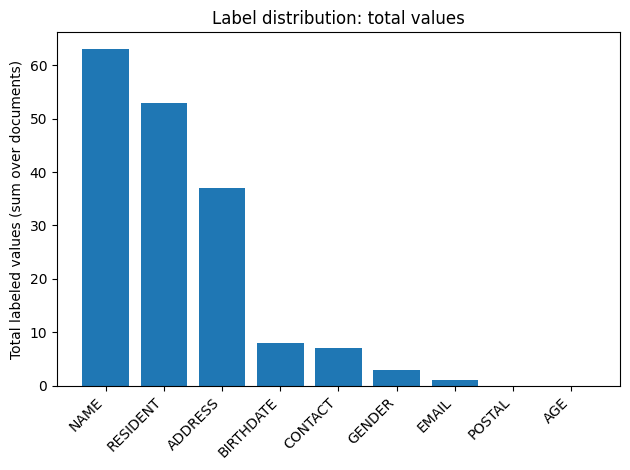

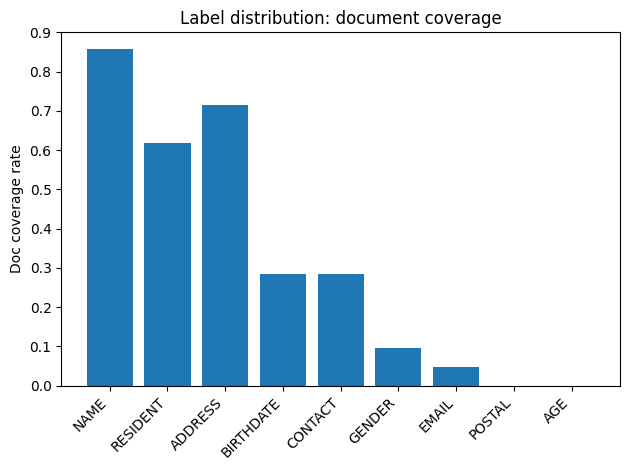

In [3]:
# 1) 필드별 총 라벨 개수(문서 전체 합)
plt.figure()
plt.bar(df["field"], df["total_values"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Total labeled values (sum over documents)")
plt.title("Label distribution: total values")
plt.tight_layout()
plt.show()

# 2) 필드별 등장 문서 비율
plt.figure()
plt.bar(df["field"], df["doc_coverage_rate"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Doc coverage rate")
plt.title("Label distribution: document coverage")
plt.tight_layout()
plt.show()

# 테스트 코드 여기부터 >>>>>>>>>>>

In [7]:
GT_PATH   = "/home/llm-ai-server/data/260128_eval/test_datasets/eval_new.jsonl"
# PRED_PATH = "/home/llm-ai-server/data/260128_eval/stage2_pred/260226_gemma3_stage2_lora_ep5_merged_ckpt-1000_None.jsonl"
PRED_PATH = "/home/llm-ai-server/data/260128_eval/stage2_pred/260226_gemma3_stage2_lora_ep5_merged_ckpt-1000_None_fixed.jsonl"

BASE_KEYS = ["NAME", "ADDRESS", "POSTAL", "RESIDENT", "CONTACT", "EMAIL", "BIRTHDATE", "GENDER", "AGE"]
# BASE_KEYS = ["name", "personal-id", "address"]
# {"NAME", "ADDRESS", "POSTAL", "RESIDENT", "CONTACT", "EMAIL", "BIRTHDATE", "GENDER", "AGE"}



GT=21  PRED=21  matched=21

=== Overall micro ===
P=0.945  R=0.912  F1=0.929   (tp=156, fp=9, fn=15)


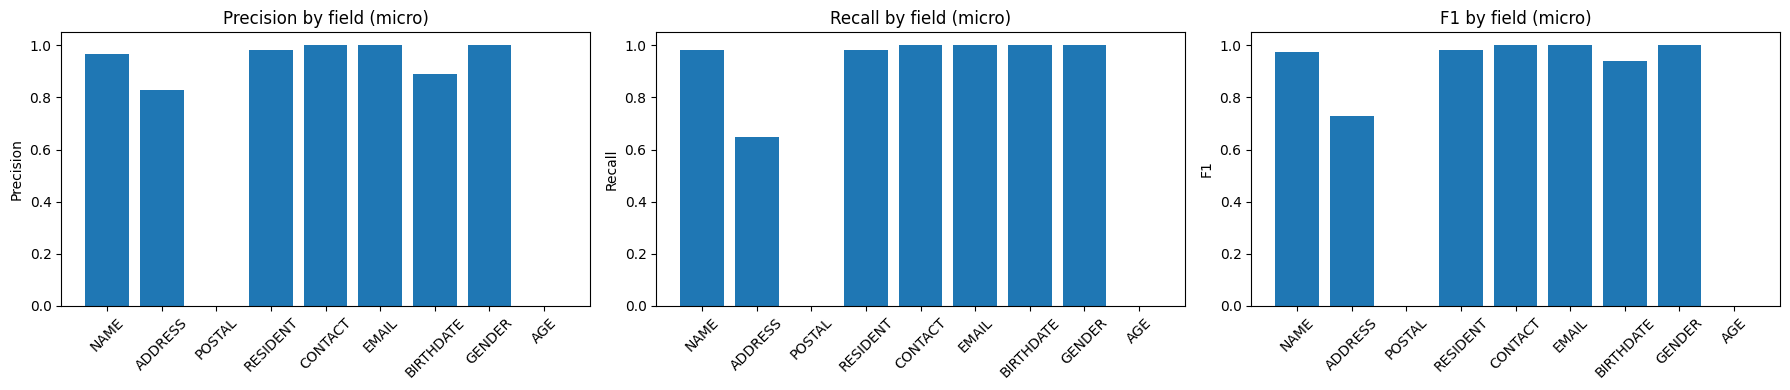


=== Worst cases (top 10) ===

- id=0021  micro_f1=0.667  meta={'source': 'text', 'doc_type': '사업자등록증', 'complexity': 'easy', 'char_len': 337}
  MISS: {'ADDRESS': ['강원도 춘천시 강원대학길 1. 3동(효자동 강원대학교 태백관)']}
  EXTRA: {'ADDRESS': ['강원도 춘천시 강원대학길 1. 3동(효자동 강원대학교 태백관 본점소재지 강원도 춘천시 강원대학길 3동(효자동 강원대학교 태백관)']}

- id=0009  micro_f1=0.667  meta={'source': 'ocr', 'doc_type': '등기부등본', 'complexity': 'hard', 'char_len': 4075}
  MISS: {'NAME': ['양성현'], 'ADDRESS': ['경기도 과천시 과천대로7나길 25, 11층(갈현동)', '고덕동 고덕센트럴', '고덕현대', '서울특별시 서초구 방배천로20길 1, 3층(방배동 새원빌딩)', '서울특별시 송파구 오금로35길 17, 36동 203호(오금동, 현대아파', '푸르지오'], 'RESIDENT': ['700413-']}
  EXTRA: {'ADDRESS': ['경기도 과천시 과천대로7나길 25, 11층(갈현동) 공고방법 회사', '서울특별시 송파구 오금로35길 17, 36동']}

- id=0008  micro_f1=0.750  meta={'source': 'ocr', 'doc_type': '지방세납입증명서', 'complexity': 'mid', 'char_len': 2488}
  MISS: {}
  EXTRA: {'NAME': ['서명 또는 인', '에이아이답']}

- id=0006  micro_f1=0.800  meta={'source': 'text', 'doc_type': '국세납입증명서', 'complexity': 'easy', 'char_len': 1069}
  MISS: {}


In [ ]:
import os
import json
from collections import Counter
import matplotlib.pyplot as plt

# # =====================
# # 0) 파일 경로 지정
# # =====================
# BASE_KEYS = ["name","personal-id","contact","email","address","postal-code"]
# BASE_KEYS = ["name"]

# =====================
# 1) util
# =====================
def assert_exists(path: str, name: str):
    if not os.path.exists(path):
        raise FileNotFoundError(f"{name} not found: {path}")

def load_jsonl(path: str):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

def normalize_obj(obj):
    """dict or json-string -> dict(key->list[str])"""
    if obj is None:
        obj = {}
    if isinstance(obj, str):
        obj = obj.strip()
        if obj:
            obj = json.loads(obj)
        else:
            obj = {}
    if not isinstance(obj, dict):
        obj = {}
    out = {k: [] for k in BASE_KEYS}
    for k in BASE_KEYS:
        v = obj.get(k, [])
        if v is None: v = []
        if isinstance(v, list):
            out[k] = [str(x) for x in v if x is not None]
        else:
            out[k] = [str(v)]
    return out

def to_set_dict(d):
    return {k: set(d.get(k, []) or []) for k in BASE_KEYS}

def prf(tp, fp, fn):
    p = tp / (tp + fp) if (tp + fp) else 0.0
    r = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = (2*p*r/(p+r)) if (p+r) else 0.0
    return p, r, f1

def eval_pair(gold, pred):
    g = to_set_dict(gold)
    p = to_set_dict(pred)
    by_key = {}
    tp_all=fp_all=fn_all=0
    for k in BASE_KEYS:
        tp = len(g[k] & p[k])
        fp = len(p[k] - g[k])
        fn = len(g[k] - p[k])
        P,R,F1 = prf(tp,fp,fn)
        by_key[k] = {"tp":tp,"fp":fp,"fn":fn,"precision":P,"recall":R,"f1":F1}
        tp_all += tp; fp_all += fp; fn_all += fn
    Pm,Rm,F1m = prf(tp_all, fp_all, fn_all)
    micro = {"tp":tp_all,"fp":fp_all,"fn":fn_all,"precision":Pm,"recall":Rm,"f1":F1m}
    return by_key, micro

def diff(gold, pred):
    g = to_set_dict(gold)
    p = to_set_dict(pred)
    miss = {k: sorted(g[k] - p[k]) for k in BASE_KEYS if (g[k] - p[k])}
    extra = {k: sorted(p[k] - g[k]) for k in BASE_KEYS if (p[k] - g[k])}
    return miss, extra

# =====================
# 2) load + match
# =====================
assert_exists(GT_PATH, "GT_PATH")
assert_exists(PRED_PATH, "PRED_PATH")

gt_rows = load_jsonl(GT_PATH)
pred_rows = load_jsonl(PRED_PATH)

# gold label key 자동 감지
gold_label_key = "label"
if gt_rows and ("label" not in gt_rows[0]) and ("label_values" in gt_rows[0]):
    gold_label_key = "label_values"

gt_map = {r["id"]: r for r in gt_rows if "id" in r}
pred_map = {r["id"]: r for r in pred_rows if "id" in r}

ids = sorted(set(gt_map) & set(pred_map))
print(f"GT={len(gt_map)}  PRED={len(pred_map)}  matched={len(ids)}")

# =====================
# 3) evaluate (micro aggregation)
# =====================
agg = {k: Counter() for k in BASE_KEYS}
worst = []

for doc_id in ids:
    gold = normalize_obj(gt_map[doc_id].get(gold_label_key, {}))
    pred = normalize_obj(pred_map[doc_id].get("response", {}))

    by_key, micro = eval_pair(gold, pred)

    for k in BASE_KEYS:
        agg[k]["tp"] += by_key[k]["tp"]
        agg[k]["fp"] += by_key[k]["fp"]
        agg[k]["fn"] += by_key[k]["fn"]

    miss, extra = diff(gold, pred)
    if miss or extra:
        worst.append((micro["f1"], doc_id, miss, extra, {
            "source": gt_map[doc_id].get("source"),
            "doc_type": gt_map[doc_id].get("doc_type"),
            "complexity": gt_map[doc_id].get("complexity"),
            "char_len": gt_map[doc_id].get("char_len"),
        }))

# overall micro
tp_all = sum(agg[k]["tp"] for k in BASE_KEYS)
fp_all = sum(agg[k]["fp"] for k in BASE_KEYS)
fn_all = sum(agg[k]["fn"] for k in BASE_KEYS)
P_over, R_over, F1_over = prf(tp_all, fp_all, fn_all)

print("\n=== Overall micro ===")
print(f"P={P_over:.3f}  R={R_over:.3f}  F1={F1_over:.3f}   (tp={tp_all}, fp={fp_all}, fn={fn_all})")

# per-field arrays
fields = BASE_KEYS
prec = []
rec  = []
f1s  = []
for k in fields:
    tp, fp, fn = agg[k]["tp"], agg[k]["fp"], agg[k]["fn"]
    P, R, F1 = prf(tp, fp, fn)
    prec.append(P); rec.append(R); f1s.append(F1)

# =====================
# 4) visualize (1x3)
# =====================
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].bar(fields, prec)
axes[0].set_title("Precision by field (micro)")
axes[0].set_ylabel("Precision")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(fields, rec)
axes[1].set_title("Recall by field (micro)")
axes[1].set_ylabel("Recall")
axes[1].tick_params(axis="x", rotation=45)

axes[2].bar(fields, f1s)
axes[2].set_title("F1 by field (micro)")
axes[2].set_ylabel("F1")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# =====================
# 5) worst cases top 10
# =====================
worst.sort(key=lambda x: x[0])  # f1 asc
print("\n=== Worst cases (top 10) ===")
for f1, doc_id, miss, extra, meta in worst:
    print(f"\n- id={doc_id}  micro_f1={f1:.3f}  meta={meta}")
    print("  MISS:", miss)
    print("  EXTRA:", extra)

In [12]:
import os, json
from collections import Counter

# ✅ 너가 말한 6개만
# FIELDS = ["name","personal-id","contact","email","address","postal-code"]
FIELDS = BASE_KEYS
# ---------- utils ----------
def load_jsonl(path: str):
    rows=[]
    with open(path,"r",encoding="utf-8") as f:
        for line in f:
            line=line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

def normalize_obj(obj):
    """dict or json-str -> dict(field->list[str])"""
    if obj is None: obj = {}
    if isinstance(obj, str):
        obj = obj.strip()
        obj = json.loads(obj) if obj else {}
    if not isinstance(obj, dict):
        obj = {}
    out = {k: [] for k in FIELDS}
    for k in FIELDS:
        v = obj.get(k, [])
        if v is None: v = []
        if isinstance(v, list):
            out[k] = [str(x) for x in v if x is not None]
        else:
            out[k] = [str(v)]
    return out

def to_set_dict(d):
    return {k: set(d.get(k, []) or []) for k in FIELDS}

def prf(tp, fp, fn):
    p = tp/(tp+fp) if (tp+fp) else 0.0
    r = tp/(tp+fn) if (tp+fn) else 0.0
    f1 = (2*p*r/(p+r)) if (p+r) else 0.0
    return p, r, f1

def fmt(x, nd=3):
    return f"{x:.{nd}f}"

# ---------- load ----------
gt_rows = load_jsonl(GT_PATH)
pred_rows = load_jsonl(PRED_PATH)

gold_label_key = "label"
if gt_rows and ("label" not in gt_rows[0]) and ("label_values" in gt_rows[0]):
    gold_label_key = "label_values"

gt_map = {r["id"]: r for r in gt_rows if "id" in r}
pred_map = {r["id"]: r for r in pred_rows if "id" in r}

ids = sorted(set(gt_map) & set(pred_map))
print(f"GT={len(gt_map)}  PRED={len(pred_map)}  matched={len(ids)}")

# ---------- eval ----------
agg = {k: Counter() for k in FIELDS}
exact_match = 0
worst = []  # (f1, id, fp, fn)

for doc_id in ids:
    gold = normalize_obj(gt_map[doc_id].get(gold_label_key, {}))
    pred = normalize_obj(pred_map[doc_id].get("response", {}))

    g = to_set_dict(gold)
    p = to_set_dict(pred)

    tp_all=fp_all=fn_all=0
    for k in FIELDS:
        tp = len(g[k] & p[k])
        fp = len(p[k] - g[k])
        fn = len(g[k] - p[k])

        agg[k]["tp"] += tp
        agg[k]["fp"] += fp
        agg[k]["fn"] += fn

        tp_all += tp; fp_all += fp; fn_all += fn

    # doc exact match (all fields exact)
    if all(g[k] == p[k] for k in FIELDS):
        exact_match += 1

    Pm, Rm, F1m = prf(tp_all, fp_all, fn_all)
    worst.append((F1m, doc_id, fp_all, fn_all))

# overall micro
tp_total = sum(agg[k]["tp"] for k in FIELDS)
fp_total = sum(agg[k]["fp"] for k in FIELDS)
fn_total = sum(agg[k]["fn"] for k in FIELDS)
P_over, R_over, F1_over = prf(tp_total, fp_total, fn_total)

print("\n=== Overall (micro) ===")
print(f"P={fmt(P_over)}  R={fmt(R_over)}  F1={fmt(F1_over)}   (TP={tp_total}, FP={fp_total}, FN={fn_total})")

em_rate = exact_match / len(ids) if ids else 0.0
print("\n=== Doc Exact Match ===")
print(f"ExactMatch={fmt(em_rate)}  ({exact_match}/{len(ids)})")

# field table (nice text)
print("\n=== Per-field (micro) ===")
header = f"{'field':14s}  {'TP':>5s} {'FP':>5s} {'FN':>5s}   {'P':>6s} {'R':>6s} {'F1':>6s}"
print(header)
print("-"*len(header))

for k in FIELDS:
    tp, fp, fn = agg[k]["tp"], agg[k]["fp"], agg[k]["fn"]
    P, R, F1 = prf(tp, fp, fn)
    print(f"{k:14s}  {tp:5d} {fp:5d} {fn:5d}   {fmt(P):>6s} {fmt(R):>6s} {fmt(F1):>6s}")

# worst cases
worst.sort(key=lambda x: x[0])
print("\n=== Worst docs (top 10 by doc F1) ===")
for f1, doc_id, fp, fn in worst[:10]:
    print(f"- id={doc_id}  docF1={fmt(f1)}  FP={fp}  FN={fn}")

GT=21  PRED=21  matched=21

=== Overall (micro) ===
P=0.941  R=0.930  F1=0.935   (TP=159, FP=10, FN=12)

=== Doc Exact Match ===
ExactMatch=0.571  (12/21)

=== Per-field (micro) ===
field              TP    FP    FN        P      R     F1
--------------------------------------------------------
NAME               61     3     1    0.953  0.984  0.968
ADDRESS            31     4     6    0.886  0.838  0.861
POSTAL              0     0     0    0.000  0.000  0.000
RESIDENT           49     1     4    0.980  0.925  0.951
CONTACT             7     0     0    1.000  1.000  1.000
EMAIL               1     0     0    1.000  1.000  1.000
BIRTHDATE           7     2     1    0.778  0.875  0.824
GENDER              3     0     0    1.000  1.000  1.000
AGE                 0     0     0    0.000  0.000  0.000

=== Worst docs (top 10 by doc F1) ===
- id=0011  docF1=0.500  FP=1  FN=1
- id=0021  docF1=0.571  FP=2  FN=1
- id=0006  docF1=0.800  FP=1  FN=0
- id=0017  docF1=0.833  FP=1  FN=1
- id=0009  d

In [9]:
import json
import re
from collections import Counter, defaultdict

import pandas as pd
from IPython.display import display

# FIELDS = ["name", "personal-id", "contact", "email", "address", "postal-code"]
FIELDS = BASE_KEYS
# =====================
# 1) 로드/정리 유틸
# =====================
def load_jsonl(path: str):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

def safe_json_loads(s: str):
    try:
        return json.loads(s)
    except Exception:
        return None

def normalize_obj(obj):
    """
    obj: dict OR json-string OR None
    -> dict(field -> list[str]) (missing field -> [])
    """
    if obj is None:
        obj = {}
    if isinstance(obj, str):
        t = obj.strip()
        if t:
            parsed = safe_json_loads(t)
            obj = parsed if isinstance(parsed, dict) else {}
        else:
            obj = {}
    if not isinstance(obj, dict):
        obj = {}
    out = {k: [] for k in FIELDS}
    for k in FIELDS:
        v = obj.get(k, [])
        if v is None:
            v = []
        if isinstance(v, list):
            out[k] = [str(x) for x in v if x is not None]
        else:
            out[k] = [str(v)]
    return out

def to_set_dict(d):
    return {k: set(d.get(k, []) or []) for k in FIELDS}

def prf(tp, fp, fn):
    p = tp / (tp + fp) if (tp + fp) else 0.0
    r = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = (2 * p * r / (p + r)) if (p + r) else 0.0
    return p, r, f1

def is_all_empty(d):
    return all(len(d.get(k, []) or []) == 0 for k in FIELDS)

# =====================
# 2) Normalized(진단용) 규칙
#   - Strict는 그대로(원문 완전일치)
#   - Normalized는 '표기 차이'만 줄이기
# =====================
_non_digit = re.compile(r"[^0-9]")
_space = re.compile(r"\s+")

def norm_value(field: str, s: str) -> str:
    if s is None:
        return ""
    s = str(s).strip()

    if field in ["personal-id", "contact", "postal-code"]:
        # 숫자만 남김 (하이픈/공백/괄호 제거)
        return _non_digit.sub("", s)

    if field == "email":
        # 대소문자/공백 차이만 제거
        return _space.sub("", s).lower()

    if field == "name":
        # 과한 정규화 금지(진단용 최소만)
        s = re.sub(r"^(이름|성명|대표자|의사명|국문성명|영문성명)\s*[:：]?\s*", "", s)
        s = _space.sub(" ", s).strip()
        return s

    if field == "address":
        # 주소는 정규화 최소: 공백만 정리
        s = _space.sub(" ", s).strip()
        return s

    return s

def normalize_for_diag(d):
    out = {}
    for k in FIELDS:
        vals = d.get(k, []) or []
        out[k] = [norm_value(k, v) for v in vals if str(v).strip() != ""]
    return out

# =====================
# 3) 평가 본체 (Strict + Normalized)
# =====================
gt_rows = load_jsonl(GT_PATH)
pred_rows = load_jsonl(PRED_PATH)

gold_label_key = "label"
if gt_rows and ("label" not in gt_rows[0]) and ("label_values" in gt_rows[0]):
    gold_label_key = "label_values"

gt_map = {r["id"]: r for r in gt_rows if "id" in r}
pred_map = {r["id"]: r for r in pred_rows if "id" in r}
ids = sorted(set(gt_map) & set(pred_map))

print(f"GT={len(gt_map)}  PRED={len(pred_map)}  matched={len(ids)}")

# --- 집계용 ---
agg_strict = {k: Counter() for k in FIELDS}  # tp/fp/fn/support
agg_norm   = {k: Counter() for k in FIELDS}  # tp/fp/fn/support (diagnostic)

doc_exact_match = 0

empty_gold_total = 0
empty_gold_pred_nonempty = 0
empty_gold_fp_sum = 0

# segment 분해 (source/doc_type)
seg_strict = defaultdict(lambda: Counter())  # tp/fp/fn/n

for doc_id in ids:
    g_row = gt_map[doc_id]
    p_row = pred_map[doc_id]

    gold_raw = normalize_obj(g_row.get(gold_label_key, {}))
    pred_raw = normalize_obj(p_row.get("response", {}))

    # Strict sets
    gS = to_set_dict(gold_raw)
    pS = to_set_dict(pred_raw)

    # 문서 완전일치(Strict, 모든 필드 동일)
    if all(gS[k] == pS[k] for k in FIELDS):
        doc_exact_match += 1

    # 빈 문서 오탐율(정답이 전부 []인데 예측이 나오면 FP)
    if is_all_empty(gold_raw):
        empty_gold_total += 1
        fp_doc = sum(len(pS[k]) for k in FIELDS)
        empty_gold_fp_sum += fp_doc
        if fp_doc > 0:
            empty_gold_pred_nonempty += 1

    # Segment keys
    source = g_row.get("source", "unknown")
    doc_type = g_row.get("doc_type", "unknown")
    seg_keys = [f"source={source}", f"doc_type={doc_type}"]

    # ---- Strict: per field counts + doc micro counts
    tp_all = fp_all = fn_all = 0
    for k in FIELDS:
        tp = len(gS[k] & pS[k])
        fp = len(pS[k] - gS[k])
        fn = len(gS[k] - pS[k])
        support = len(gS[k])  # = TP + FN

        agg_strict[k]["tp"] += tp
        agg_strict[k]["fp"] += fp
        agg_strict[k]["fn"] += fn
        agg_strict[k]["support"] += support

        tp_all += tp
        fp_all += fp
        fn_all += fn

    # segment micro (strict)
    for sk in seg_keys:
        seg_strict[sk]["tp"] += tp_all
        seg_strict[sk]["fp"] += fp_all
        seg_strict[sk]["fn"] += fn_all
        seg_strict[sk]["n"]  += 1

    # ---- Normalized(진단용)
    gold_norm = normalize_for_diag(gold_raw)
    pred_norm = normalize_for_diag(pred_raw)
    gN = to_set_dict(gold_norm)
    pN = to_set_dict(pred_norm)

    for k in FIELDS:
        tp = len(gN[k] & pN[k])
        fp = len(pN[k] - gN[k])
        fn = len(gN[k] - pN[k])
        support = len(gN[k])

        agg_norm[k]["tp"] += tp
        agg_norm[k]["fp"] += fp
        agg_norm[k]["fn"] += fn
        agg_norm[k]["support"] += support

# =====================
# 4) DataFrame 생성
# =====================

# ---- 전체(Strict micro)
tp_total = sum(agg_strict[k]["tp"] for k in FIELDS)
fp_total = sum(agg_strict[k]["fp"] for k in FIELDS)
fn_total = sum(agg_strict[k]["fn"] for k in FIELDS)
P_over, R_over, F1_over = prf(tp_total, fp_total, fn_total)

summary_df = pd.DataFrame([{
    "GT": len(gt_map),
    "PRED": len(pred_map),
    "matched": len(ids),
    "TP": tp_total,
    "FP": fp_total,
    "FN": fn_total,
    "P": P_over,
    "R": R_over,
    "F1": F1_over,
}])

# ---- 필드별(Strict micro)
per_field_rows = []
for k in FIELDS:
    tp = int(agg_strict[k]["tp"])
    fp = int(agg_strict[k]["fp"])
    fn = int(agg_strict[k]["fn"])
    support = int(agg_strict[k]["support"])  # TP+FN
    P, R, F1 = prf(tp, fp, fn)
    per_field_rows.append({
        "field": k,
        "TP+FN": support,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "P": P,
        "R": R,
        "F1": F1,
    })

per_field_df = pd.DataFrame(per_field_rows)
per_field_df["field"] = pd.Categorical(per_field_df["field"], categories=FIELDS, ordered=True)
per_field_df = per_field_df.sort_values("field").reset_index(drop=True)

# ---- 문서 완전일치
em = doc_exact_match / len(ids) if ids else 0.0
doc_exact_df = pd.DataFrame([{
    "ExactMatch": em,
    "matched_docs": len(ids),
    "exact_docs": doc_exact_match,
}])

# ---- 빈 문서 오탐율
if empty_gold_total == 0:
    empty_gold_df = pd.DataFrame([{
        "EmptyGoldDocs": 0,
        "PredNonEmptyRate": None,
        "AvgFPperEmptyDoc": None,
        "note": "정답이 전부 []인 문서 없음",
    }])
else:
    empty_gold_df = pd.DataFrame([{
        "EmptyGoldDocs": empty_gold_total,
        "PredNonEmptyRate": empty_gold_pred_nonempty / empty_gold_total,
        "AvgFPperEmptyDoc": empty_gold_fp_sum / empty_gold_total,
        "note": "",
    }])

# ---- segment breakdown DF
def segment_df(prefix: str):
    rows = []
    for seg, st in seg_strict.items():
        if not seg.startswith(prefix):
            continue
        tp = int(st["tp"]); fp = int(st["fp"]); fn = int(st["fn"]); n = int(st["n"])
        P, R, F1 = prf(tp, fp, fn)
        rows.append({
            "segment": seg,
            "n": n,
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "P": P,
            "R": R,
            "F1": F1,
        })
    df = pd.DataFrame(rows)
    if len(df):
        df = df.sort_values("F1", ascending=True).reset_index(drop=True)  # WORST -> BEST
    return df

seg_source_df  = segment_df("source=")
seg_doctype_df = segment_df("doc_type=")

# ---- Strict vs Normalized gap
gap_rows = []
for k in FIELDS:
    tpS, fpS, fnS = int(agg_strict[k]["tp"]), int(agg_strict[k]["fp"]), int(agg_strict[k]["fn"])
    tpN, fpN, fnN = int(agg_norm[k]["tp"]),   int(agg_norm[k]["fp"]),   int(agg_norm[k]["fn"])

    PS, RS, F1S = prf(tpS, fpS, fnS)
    PN, RN, F1N = prf(tpN, fpN, fnN)

    gap_rows.append({
        "field": k,
        "F1_strict": F1S,
        "F1_norm": F1N,
        "gap": (F1N - F1S),
        "R_strict": RS,
        "R_norm": RN,
    })

gap_df = pd.DataFrame(gap_rows)
gap_df["field"] = pd.Categorical(gap_df["field"], categories=FIELDS, ordered=True)
gap_df = gap_df.sort_values("field").reset_index(drop=True)

# =====================
# 5) 주피터에서 DF로 출력
# =====================
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

print("✅ summary_df")
display(summary_df)

print("✅ per_field_df")
display(per_field_df)

print("✅ doc_exact_df")
display(doc_exact_df)

print("✅ empty_gold_df")
display(empty_gold_df)

print("✅ seg_source_df (WORST -> BEST)")
display(seg_source_df)

print("✅ seg_doctype_df (WORST -> BEST)")
display(seg_doctype_df)

print("✅ gap_df")
display(gap_df)

GT=21  PRED=21  matched=21
✅ summary_df


,GT,PRED,matched,TP,FP,FN,P,R,F1
0,21,21,21,156,9,15,0.945,0.912,0.929


✅ per_field_df


,field,TP+FN,TP,FP,FN,P,R,F1
0,NAME,62,61,2,1,0.968,0.984,0.976
1,ADDRESS,37,24,5,13,0.828,0.649,0.727
2,POSTAL,0,0,0,0,0.000,0.000,0.000
3,RESIDENT,53,52,1,1,0.981,0.981,0.981
4,CONTACT,7,7,0,0,1.000,1.000,1.000
5,EMAIL,1,1,0,0,1.000,1.000,1.000
6,BIRTHDATE,8,8,1,0,0.889,1.000,0.941
7,GENDER,3,3,0,0,1.000,1.000,1.000
8,AGE,0,0,0,0,0.000,0.000,0.000


✅ doc_exact_df


...

,segment,n,TP,FP,FN,P,R,F1
0,source=ocr,16,74,7,14,0.914,0.841,0.876
1,source=text,5,82,2,1,0.976,0.988,0.982


✅ seg_doctype_df (WORST -> BEST)


,segment,n,TP,FP,FN,P,R,F1
0,doc_type=등기부등본,1,10,2,8,0.833,0.556,0.667
1,doc_type=지방세납입증명서,1,3,2,0,0.600,1.000,0.750
2,doc_type=국세납입증명서,1,2,1,0,0.667,1.000,0.800
3,doc_type=사업자등록증,2,4,1,1,0.800,0.800,0.800
4,doc_type=주민등록초본,1,15,2,5,0.882,0.750,0.811
5,doc_type=주민등록등본,1,5,1,1,0.833,0.833,0.833
6,doc_type=가족관계증명서,1,13,0,0,1.000,1.000,1.000
7,doc_type=4대보험완납증명서,1,1,0,0,1.000,1.000,1.000
8,doc_type=경력증명서,1,8,0,0,1.000,1.000,1.000
9,doc_type=건강보험자격득실확인서,1,2,0,0,1.000,1.000,1.000


✅ gap_df


,field,F1_strict,F1_norm,gap,R_strict,R_norm
0,NAME,0.976,0.976,0.000,0.984,0.984
1,ADDRESS,0.727,0.727,0.000,0.649,0.649
2,POSTAL,0.000,0.000,0.000,0.000,0.000
3,RESIDENT,0.981,0.981,0.000,0.981,0.981
4,CONTACT,1.000,1.000,0.000,1.000,1.000
5,EMAIL,1.000,1.000,0.000,1.000,1.000
6,BIRTHDATE,0.941,0.941,0.000,1.000,1.000
7,GENDER,1.000,1.000,0.000,1.000,1.000
8,AGE,0.000,0.000,0.000,0.000,0.000
